In [1]:
from utils import *
from FAPT import *
from DRAG import *
import matplotlib.pyplot as plt

full_symbolic = False
rH = 2
rW = 1
use_gauss = True
s = Simulation()
dim_q1, dim_q2, dim_c = (3,3,3)

tg_sym = sp.Symbol("t_g", real=True, positive=True)
sigma_sym = sp.Symbol(r"\sigma", real=True, positive=True)
tsym = sp.Symbol("t", real=True, positive=True)

wd_sym = sp.Function(r"\omega_d", real=True)(tsym)
Ar_sym = sp.Function("A_r", real=True)(tsym)
Ai_sym = sp.Function("A_i", real=True)(tsym)
A_t_sym = Ar_sym + sp.I * Ai_sym

factor = sp.Symbol("f", real=True, positive=True)
A0, _ = gauss(tsym, factor, tg_sym, sigma_sym * tg_sym, True) if use_gauss else tanh(tsym, factor, tg_sym, sigma_sym, True) 
wd0 = sp.Symbol(r"\omega_{d,0}", real=True)
# 2. Dynamic State/Matrix Init (Symbolisch vs. Numerisch)
D = 27
V0_sym = sp.zeros(D, D)

if full_symbolic:
  # --- SYMBOLISCHER PFAD ---
  E_array_sym = np.array([sp.Symbol(f"E_{i}", real=True) for i in range(D)])

  V1_dressed_ref = s.V1_dressed_array
  threshold = 1e-4
  V1_sym = np.zeros((D, D), dtype=object)

  for i1 in range(dim_q1):
    for i2 in range(dim_q2):
      for ic in range(dim_c):
        for jc in range(dim_c):
          for j1 in range(dim_q1):
            for j2 in range(dim_q2):
              i = i1 * dim_c * dim_q2 + ic * dim_q2 + i2
              j = j1 * dim_c * dim_q2 + jc * dim_q2 + j2

              if np.abs(V1_dressed_ref[i, j]) >= threshold:
                real = True
                bra_ket = sp.Symbol(
                    f"\\bra{{{i1}{ic}{i2}}}\\widetilde{{V_1}}{{\\ket{{{j1}{jc}{j2}}}}}",
                    real=real,
                )
                V1_sym[i, j] = bra_ket
              else:
                V1_sym[i, j] = sp.S.Zero
                  # Physikalische Parameter
else:
  # --- NUMERISCHER PFAD ---
  E_array_sym = np.array(s.E_array, dtype=object)
  threshold = 1e-2
  V1_sym = np.array(s.V1_dressed_array, dtype=object)
  V1_sym[np.abs(np.asarray(s.V1_dressed_array, dtype=complex)) < threshold] = 0.0
A0


f*(exp(-(t - t_g/2)**2/(2*\sigma**2*t_g**2)) - exp(-1/(8*\sigma**2)))

Create the effective Hamiltonian with symbolic dependencies

In [2]:
Heff_sym = Heff_Floquet_total_matrix_summed(rH=rH,wd=wd_sym,A=A_t_sym,resonances=s.resonances,E=E_array_sym,V_posHarm=V1_sym,                
    ref_state=getattr(s, 'ref_state', None),dwd=0,dA=0,t=tsym,analytics=True,include_geometric=False,include_micromotion=False,include_g_correction=False,verbose=False,rW=rW)
H_eff_raw = sp.Matrix(Heff_sym)
delta_shift = H_eff_raw[0, 0]
Heff = H_eff_raw - delta_shift * sp.eye(H_eff_raw.shape[0])

Heff_sym_0 = Heff_Floquet_total_matrix_summed(rH=rH,wd=wd0,A=A0,resonances=s.resonances,E=E_array_sym,V_posHarm=V1_sym,
                                              dwd=0,dA=0,t=tsym,analytics=True,include_geometric=False,include_micromotion=False,include_g_correction=False,verbose=False,rW=rW)
H_eff_raw = sp.Matrix(Heff_sym_0)
delta_shift = H_eff_raw[0, 0]
Heff0 = H_eff_raw - delta_shift * sp.eye(H_eff_raw.shape[0])

In [3]:
# implement equations leading to drag:
Delta_sol = Heff[2,2] - 2*Heff[1,1]
rrr_sol = Heff[0,1]/Heff[1,2]
if full_symbolic:
    Delta = sy.symbols("\\Delta")
    rrr = sy.symbols("\\lambda")
else:
    Delta = Delta_sol
    rrr = rrr_sol
dOab0_dt = Heff0[0,1].diff(tsym)

full_sol = False
if full_sol:
    eq1 = sp.Eq(1/2*sp.re(Heff[0,1]),  sp.simplify(1/2*Heff0[0,1]+ 1/(64*Delta**2)*(rrr**2-4)*Heff0[0,1]**3 
                                                   - (13*rrr**4-76*rrr**2+112)*Heff0[0,1]**5/(2**5*128*Delta**4)))
    eq2 = sp.Eq(1/2*sp.im(Heff[0,1]), sp.simplify(-1/2*dOab0_dt/Delta+ 33/8*(rrr**2-2)*Heff0[0,1]**2*dOab0_dt/(24*Delta**3)))
    eq3 = sp.Eq(Heff[1,1],sp.simplify((rrr**2-4)*1/2*Heff0[0,1]**2/(4*Delta)+(rrr**4-7*rrr**2+12)*1/(16**2*Delta**3)*Heff0[0,1]**4))
else:
    eq1 = sp.Eq(1/2*sp.re(Heff[0,1]),  1/2*Heff0[0,1])
    eq2 = sp.Eq(1/2*sp.im(Heff[0,1]), -1/2*dOab0_dt/Delta)
    eq3 = sp.Eq(Heff[1,1],(rrr**2-4)*1/2*Heff0[0,1]**2/(4*Delta))

display(eq1)
display(eq2)
display(eq3)

Eq(0.00531029735880245*A_r(t), 0.00531029735880245*f*(exp(-(t - t_g/2)**2/(2*\sigma**2*t_g**2)) - exp(-1/(8*\sigma**2))))

Eq(-0.00531029735880245*A_i(t), 0.00265514867940123*f*(2*t - t_g)*exp(-(t - t_g/2)**2/(2*\sigma**2*t_g**2))/(\sigma**2*t_g**2*((3.78067916982209e-5*A_i(t)**2 + 3.78067916982209e-5*A_r(t)**2)/(\omega_d(t) - 50.8583678034968) + (3.78067916982209e-5*A_i(t)**2 + 3.78067916982209e-5*A_r(t)**2)/(-\omega_d(t) - 50.8583678034968) - 2*(6.18999632320121e-5*A_i(t)**2 + 6.18999632320121e-5*A_r(t)**2)/(2*\omega_d(t) - 50.8583678034968) - 2*(7.48734189786373e-5*A_i(t)**2 + 7.48734189786373e-5*A_r(t)**2)/(2*\omega_d(t) - 53.9549652927059) + (7.73446770575243e-5*A_i(t)**2 + 7.73446770575243e-5*A_r(t)**2)/(\omega_d(t) - 53.6093835188607) + (7.73446770575243e-5*A_i(t)**2 + 7.73446770575243e-5*A_r(t)**2)/(3*\omega_d(t) - 53.6093835188607) + (0.000106790955719789*A_i(t)**2 + 0.000106790955719789*A_r(t)**2)/(3*\omega_d(t) - 58.2216291587691) + (0.000106790955719789*A_i(t)**2 + 0.000106790955719789*A_r(t)**2)/(\omega_d(t) - 58.2216291587691) - 3*(0.000112797032155617*A_i(t)**2 + 0.000112797032155617*A_r(t)*

Eq(-(3.78067916982209e-5*A_i(t)**2 + 3.78067916982209e-5*A_r(t)**2)/(\omega_d(t) - 50.8583678034968) - (3.78067916982209e-5*A_i(t)**2 + 3.78067916982209e-5*A_r(t)**2)/(-\omega_d(t) - 50.8583678034968) + (6.18999632320121e-5*A_i(t)**2 + 6.18999632320121e-5*A_r(t)**2)/(2*\omega_d(t) - 50.8583678034968) + (7.48734189786373e-5*A_i(t)**2 + 7.48734189786373e-5*A_r(t)**2)/(2*\omega_d(t) - 53.9549652927059) + (0.000112797032155617*A_i(t)**2 + 0.000112797032155617*A_r(t)**2)/\omega_d(t) - (0.000113865290241024*A_i(t)**2 + 0.000113865290241024*A_r(t)**2)/(\omega_d(t) - 45.1772192692561) - (0.000113865290241024*A_i(t)**2 + 0.000113865290241024*A_r(t)**2)/(-\omega_d(t) - 45.1772192692561) + 4*(0.00216878308411047*A_i(t)**2 + 0.00216878308411047*A_r(t)**2)/(3*\omega_d(t)) - (0.0113261064431894*A_i(t)**2 + 0.0113261064431894*A_r(t)**2)/(2*\omega_d(t)) - 2.60480689951668e-6*A_i(t)**2 - 2.60480689951668e-6*A_r(t)**2 - \omega_d(t) + 4.43804328641986, 0.000112797032155617*f**2*(-2 + (-0.0106205947176049

In [4]:
def sanitize_expression(expr, full_symbolic=False):
    if isinstance(expr, (list, tuple)):
        return [sanitize_expression(e, full_symbolic) for e in expr]

    if full_symbolic:
        expr = sp.nsimplify(expr, constants=[sp.pi], tolerance=1e-12, full=True)

    expr = sp.powsimp(sp.expand(expr), combine="exp", force=True)
    return sp.factor(sp.cancel(sp.together(expr)))

def compact_drag_expressions(Ar, Ai, wd, Delta_expr=None, full_symbolic=False):
    expressions = [sanitize_expression(e, full_symbolic) for e in (Ar, Ai, wd)]

    common_exp = expressions[0].atoms(sp.exp) & expressions[1].atoms(sp.exp)
    if not common_exp:
        raise ValueError("Keine gemeinsame Exponentialfunktion gefunden.")

    base_exp = min(common_exp, key=lambda e: sp.count_ops(e.args[0]))
    base_arg = base_exp.args[0]

    u_sym = sp.Symbol("u", real=True)
    Delta_sym = sp.Symbol(r"\Delta", real=True)

    def replace_exponentials(expr):
        replacements = {}

        for exponential in expr.atoms(sp.exp):
            ratio = sp.simplify(exponential.args[0] / base_arg)
            ratio = sp.nsimplify(ratio) if full_symbolic else ratio

            if ratio.is_integer:
                replacements[exponential] = (u_sym + 1)**int(ratio)
            elif ratio.is_number:
                value = float(ratio)
                power = round(value)
                if abs(value - power) < 1e-10:
                    replacements[exponential] = (u_sym + 1)**power

        return expr.xreplace(replacements)

    compact = []

    for expr in expressions:
        expr = replace_exponentials(expr)
        expr = sp.factor(sp.cancel(sp.together(sp.expand(expr))))

        if Delta_expr is not None:
            Delta_clean = sanitize_expression(Delta_expr, full_symbolic)
            expr = sp.factor(expr.subs(Delta_clean, Delta_sym))

        compact.append(expr)

    return u_sym, base_exp - 1, Delta_sym, tuple(compact)

In [5]:
sigma_val = 0.3 if not full_symbolic else sigma_sym

Ar_sol = sp.solve(eq1, Ar_sym)[0]
display(Ar_sol)
eq2_sub = eq2.subs(Ar_sym, Ar_sol)
Ai_result = sp.solve(eq2_sub, Ai_sym)
Ai_sol = Ai_result[0] if isinstance(Ai_result, list) else Ai_result
display(Ai_result)

wd_result = sp.solve(eq3, wd_sym)
wd_sol = wd_result[0] if isinstance(wd_result, list) else wd_result

H01_sol = Heff0[0, 1].subs({Ar_sym: Ar_sol, Ai_sym: Ai_sol, wd_sym: wd_sol})
eq_area = sp.Eq(sp.integrate(sp.re(H01_sol), (tsym, 0, tg_sym)), sp.pi / 2)
factor_sol = sp.solve(eq_area, factor)[0].subs(sigma_sym, sigma_val)
if full_symbolic:
    factor_sol = factor
Ar_sol = Ar_sol.subs({factor: factor_sol, sigma_sym: sigma_val})
Ai_sol = Ai_sol.subs({factor: factor_sol, sigma_sym: sigma_val})
wd_sol = wd_sol.subs({factor: factor_sol, sigma_sym: sigma_val})
if not full_symbolic: Ar_sol *= factor

Ar_sol = sanitize_expression(Ar_sol, full_symbolic)
Ai_sol = sanitize_expression(Ai_sol, full_symbolic)
wd_sol = sanitize_expression(wd_sol, full_symbolic)

from IPython.display import display, Latex
def print_latex_expressions(Ar, Ai, wd):
    latex_Ar = sp.latex(Ar)
    latex_Ai = sp.latex(Ai)
    latex_wd = sp.latex(wd)
    
    # 1. Gerendertes LaTeX im Jupyter Notebook anzeigen
    display(Latex(f"$$A_r(t) = {latex_Ar}$$"))
    display(Latex(f"$$A_i(t) = {latex_Ai}$$"))
    display(Latex(f"$$\\omega_d(t) = {latex_wd}$$"))
    
    # 2. LaTeX-Code direkt zum Kopieren ausgeben
    print("\n--- LaTeX Source Code ---")
    print(f"A_r(t)    : {latex_Ar}")
    print(f"A_i(t)    : {latex_Ai}")
    print(f"omega_d(t): {latex_wd}")

x = tsym / tg_sym
u = sp.exp(sp.Rational(50, 9) * x * (1 - x)) - 1

u_sym, u_expr, Delta_sym, (Ar_compact, Ai_compact, wd_compact) = compact_drag_expressions(Ar_sol, Ai_sol, wd_sol, Delta_expr=Delta, full_symbolic=full_symbolic)

def collect_wd_terms(wd, t, tg, sigma, u):
    phi = sp.expand(t / (2 * sigma**2 * tg) - t**2 / (2 * sigma**2 * tg**2))
    replacements = {sp.exp(sp.expand(k * phi)): (u + 1)**k for k in range(-4, 5)}

    terms = []

    for term in sp.Add.make_args(sp.expand_mul(wd)):
        term = sp.powsimp(term, combine="exp", force=True)
        term = term.replace(lambda x: x.func == sp.exp, lambda x: sp.exp(sp.expand(x.args[0])))
        terms.append(term.xreplace(replacements))

    result = sp.Add(*terms)
    result = sp.factor(sp.cancel(sp.together(result)))
    return sp.collect(result, u)
wd_compact = collect_wd_terms(wd_sol, tsym, tg_sym, sigma_sym, u_sym)
# wd_compact, u_expr = simplify_wd_gaussian(wd_sol, u_sym, tsym)
display(sp.Eq(u_sym, u_expr))
print_latex_expressions(Ar_compact, Ai_compact, wd_compact)

Ar_sol = Ar_compact.subs(u_sym, u_expr)
Ai_sol = Ai_compact.subs(u_sym, u_expr)
wd_sol = wd_compact.subs(u_sym, u_expr)
rrr_sol

f*exp(-0.125*(2.0*t - t_g)**2/(\sigma**2*t_g**2)) - f*exp(-0.125/\sigma**2)

KeyboardInterrupt: 

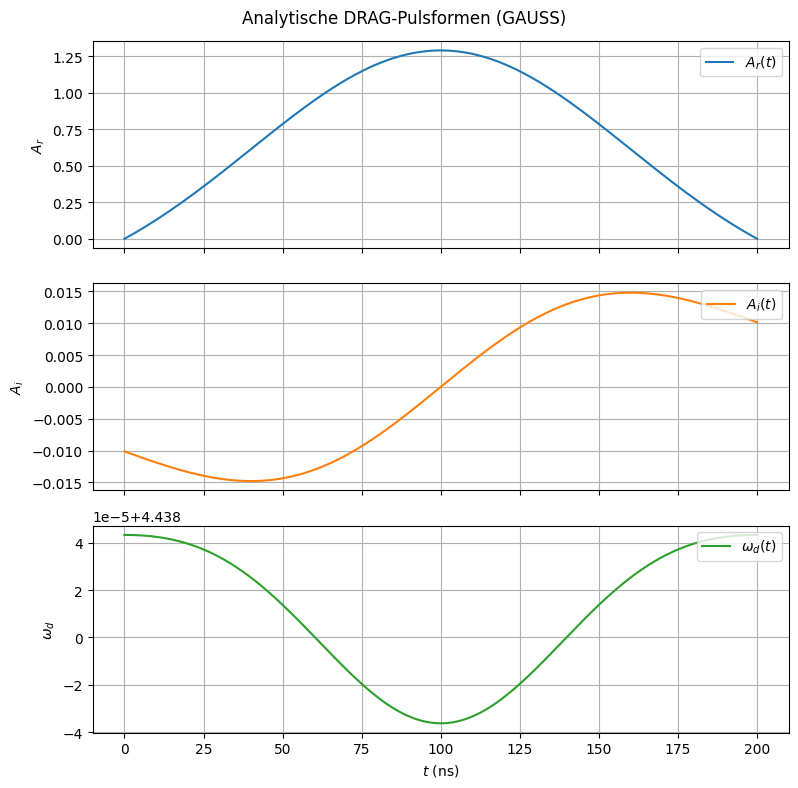

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Pulse Type wählen: gauss oder tanh
pulse_name = "gauss" if use_gauss else "tanh"

# Beispielhafte Parameter für die numerische Auswertung
tg_val = 200.0          # Gatezeit in ns
sigma_val = 0.3  # Sigma
f_val = 1.0             # Faktor f

t_num = np.linspace(0, tg_val, 500)

# Substitution der Parameter (ohne wd0)
subs_dict = {tg_sym: tg_val, sigma_sym: sigma_val, factor: f_val}

Ai_expr = Ai_sol[0] if isinstance(Ai_sol, (list, tuple)) else Ai_sol
wd_expr = wd_sol[0] if isinstance(wd_sol, (list, tuple)) else wd_sol

f_Ar = sp.lambdify(tsym, Ar_sol.subs(subs_dict), modules="numpy")
f_Ai = sp.lambdify(tsym, Ai_expr.subs(subs_dict), modules="numpy")
f_wd = sp.lambdify(tsym, wd_expr.subs(subs_dict), modules="numpy")

Ar_vals = np.vectorize(f_Ar)(t_num)
Ai_vals = np.vectorize(f_Ai)(t_num)
wd_vals = np.vectorize(f_wd)(t_num)

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t_num, Ar_vals, label=r"$A_r(t)$", color="tab:blue")
axes[0].set_ylabel(r"$A_r$")
axes[0].legend(loc="upper right")
axes[0].grid(True)

axes[1].plot(t_num, Ai_vals, label=r"$A_i(t)$", color="tab:orange")
axes[1].set_ylabel(r"$A_i$")
axes[1].legend(loc="upper right")
axes[1].grid(True)

axes[2].plot(t_num, wd_vals, label=r"$\omega_d(t)$", color="tab:green")
axes[2].set_ylabel(r"$\omega_d$")
axes[2].set_xlabel(r"$t$ (ns)")
axes[2].legend(loc="upper right")
axes[2].grid(True)

plt.suptitle(f"Analytische DRAG-Pulsformen ({pulse_name.upper()})")
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import sympy as sp
import numpy as np

SAVE_DIRECTORY = Path("operational_res/analytical_drive_data")

def save_analytical_drive(pulse_type, pulse_data, save_directory=SAVE_DIRECTORY):
    save_directory = Path(save_directory)
    save_directory.mkdir(parents=True, exist_ok=True)

    file_path = save_directory / f"analytical_drive_{pulse_type}_data.npz"

    # np.savez_compressed(
    #     file_path,
    #     pulse_type=pulse_type,
    #     Ar_srepr=sp.srepr(pulse_data["Ar"]),
    #     Ai_srepr=sp.srepr(pulse_data["Ai"]),
    #     wd_srepr=sp.srepr(pulse_data["wd"]),
    # )

    print(f"Symbolische Pulsform gespeichert: '{file_path}'")
    return file_path

# Präpariere die Lösungsdaten für das gewählte Profil (gauss oder tanh)
pulse_type = f"aa_{pulse_name}"

Ai_symbolic = Ai_sol[0] if isinstance(Ai_sol, (list, tuple)) else Ai_sol
wd_symbolic = wd_sol[0] if isinstance(wd_sol, (list, tuple)) else wd_sol

pulse_data = {
    "Ar": Ar_sol,
    "Ai": Ai_symbolic,
    "wd": wd_symbolic,
}

saved_file_path = save_analytical_drive(pulse_type=pulse_type, pulse_data=pulse_data)

Symbolische Pulsform gespeichert: 'operational_res/analytical_drive_data/analytical_drive_aa_gauss_data.npz'
